# 🎯 Customer Segmentation — K-Means Clustering

**Objective:** Segment customers into meaningful groups using unsupervised learning (K-Means), enabling targeted marketing, personalised offers, and differentiated service strategies.

**Dataset:** Synthetic E-Commerce Customer Dataset — 2,000 records · 6 features  
**Algorithm:** K-Means Clustering (Unsupervised)

---
### Project Workflow
1. Import Libraries & Generate Dataset  
2. Exploratory Data Analysis  
3. Feature Scaling  
4. Optimal K — Elbow Method & Silhouette Score  
5. K-Means Clustering  
6. Cluster Profiling & Visualisation  
7. Business Interpretation  
8. Conclusions & Strategy

## 1. Import Libraries & Generate Dataset

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing     import StandardScaler
from sklearn.cluster           import KMeans
from sklearn.metrics           import silhouette_score
from sklearn.decomposition     import PCA

matplotlib.rcParams['figure.dpi']     = 110
matplotlib.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='Set2')

print('✅  Libraries imported!')
print(f'    pandas {pd.__version__}  |  numpy {np.__version__}')

from pathlib import Path
PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Plots directory: {PLOTS_DIR.resolve()}')

✅  Libraries imported!
    pandas 3.0.3  |  numpy 2.4.4
Plots directory: C:\Users\amjad\Projects\developerhub-data-science-internship\Assignment_5\plots


In [2]:
# Reproducible synthetic e-commerce customer dataset
np.random.seed(42)
n = 2000

# Cluster 0: Low value — young, infrequent, low spend
c0 = int(n * 0.30)
age_0        = np.random.randint(18, 30, c0)
annual_income_0  = np.random.normal(28000, 5000, c0).clip(15000, 45000)
spend_score_0    = np.random.normal(35, 10, c0).clip(5, 60)
purchase_freq_0  = np.random.normal(2, 1, c0).clip(1, 5)
avg_order_val_0  = np.random.normal(45, 15, c0).clip(10, 100)
days_since_0     = np.random.normal(120, 30, c0).clip(30, 200)

# Cluster 1: Mid value — middle-aged, moderate spend
c1 = int(n * 0.40)
age_1        = np.random.randint(30, 50, c1)
annual_income_1  = np.random.normal(55000, 10000, c1).clip(30000, 90000)
spend_score_1    = np.random.normal(55, 12, c1).clip(30, 80)
purchase_freq_1  = np.random.normal(6, 2, c1).clip(3, 12)
avg_order_val_1  = np.random.normal(120, 30, c1).clip(60, 220)
days_since_1     = np.random.normal(60, 20, c1).clip(10, 120)

# Cluster 2: High value — affluent, frequent, high spend
c2 = n - c0 - c1
age_2        = np.random.randint(35, 65, c2)
annual_income_2  = np.random.normal(90000, 15000, c2).clip(60000, 150000)
spend_score_2    = np.random.normal(80, 8, c2).clip(60, 100)
purchase_freq_2  = np.random.normal(14, 3, c2).clip(8, 24)
avg_order_val_2  = np.random.normal(280, 60, c2).clip(150, 500)
days_since_2     = np.random.normal(15, 8, c2).clip(1, 40)

df = pd.DataFrame({
    'age':              np.concatenate([age_0, age_1, age_2]),
    'annual_income':    np.concatenate([annual_income_0, annual_income_1, annual_income_2]).round(0),
    'spend_score':      np.concatenate([spend_score_0, spend_score_1, spend_score_2]).round(1),
    'purchase_freq':    np.concatenate([purchase_freq_0, purchase_freq_1, purchase_freq_2]).round(1),
    'avg_order_value':  np.concatenate([avg_order_val_0, avg_order_val_1, avg_order_val_2]).round(2),
    'days_since_last':  np.concatenate([days_since_0, days_since_1, days_since_2]).round(0)
}).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset shape : {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(10)

Dataset shape : 2,000 rows x 6 columns


,age,annual_income,spend_score,purchase_freq,avg_order_value,days_since_last
0,61,79506.0,79.3,9.3,388.69,20.0
1,18,26352.0,29.0,1.0,29.90,167.0
2,41,46883.0,62.9,8.5,79.02,71.0
3,41,49874.0,72.4,6.4,150.63,19.0
4,43,44123.0,47.2,3.2,123.66,64.0
5,46,55331.0,48.4,6.2,122.32,83.0
6,31,44339.0,59.2,8.2,62.18,32.0
7,51,113843.0,89.2,14.4,278.03,11.0
8,25,26826.0,17.8,1.8,43.31,131.0
9,43,62557.0,57.2,6.7,146.29,73.0


## 2. Exploratory Data Analysis

In [3]:
print('Dataset Info:')
print(df.dtypes)
print(f'\nMissing values: {df.isnull().sum().sum()}')
print()
df.describe().round(2)

Dataset Info:
age                  int32
annual_income      float64
spend_score        float64
purchase_freq      float64
avg_order_value    float64
days_since_last    float64
dtype: object

Missing values: 0



,age,annual_income,spend_score,purchase_freq,avg_order_value,days_since_last
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,37.83,57763.26,56.44,7.29,145.64,64.37
std,12.01,26745.75,20.15,5.12,99.84,45.55
min,18.00,15000.00,5.00,1.00,10.00,1.00
25%,27.00,32771.50,40.10,3.00,60.00,21.00
50%,38.00,54728.50,55.80,6.10,119.14,60.00
75%,47.00,76984.50,74.30,11.20,221.96,96.00
max,64.00,140661.00,100.00,21.60,454.85,196.00


Saved: plot_01_feature_distributions.png


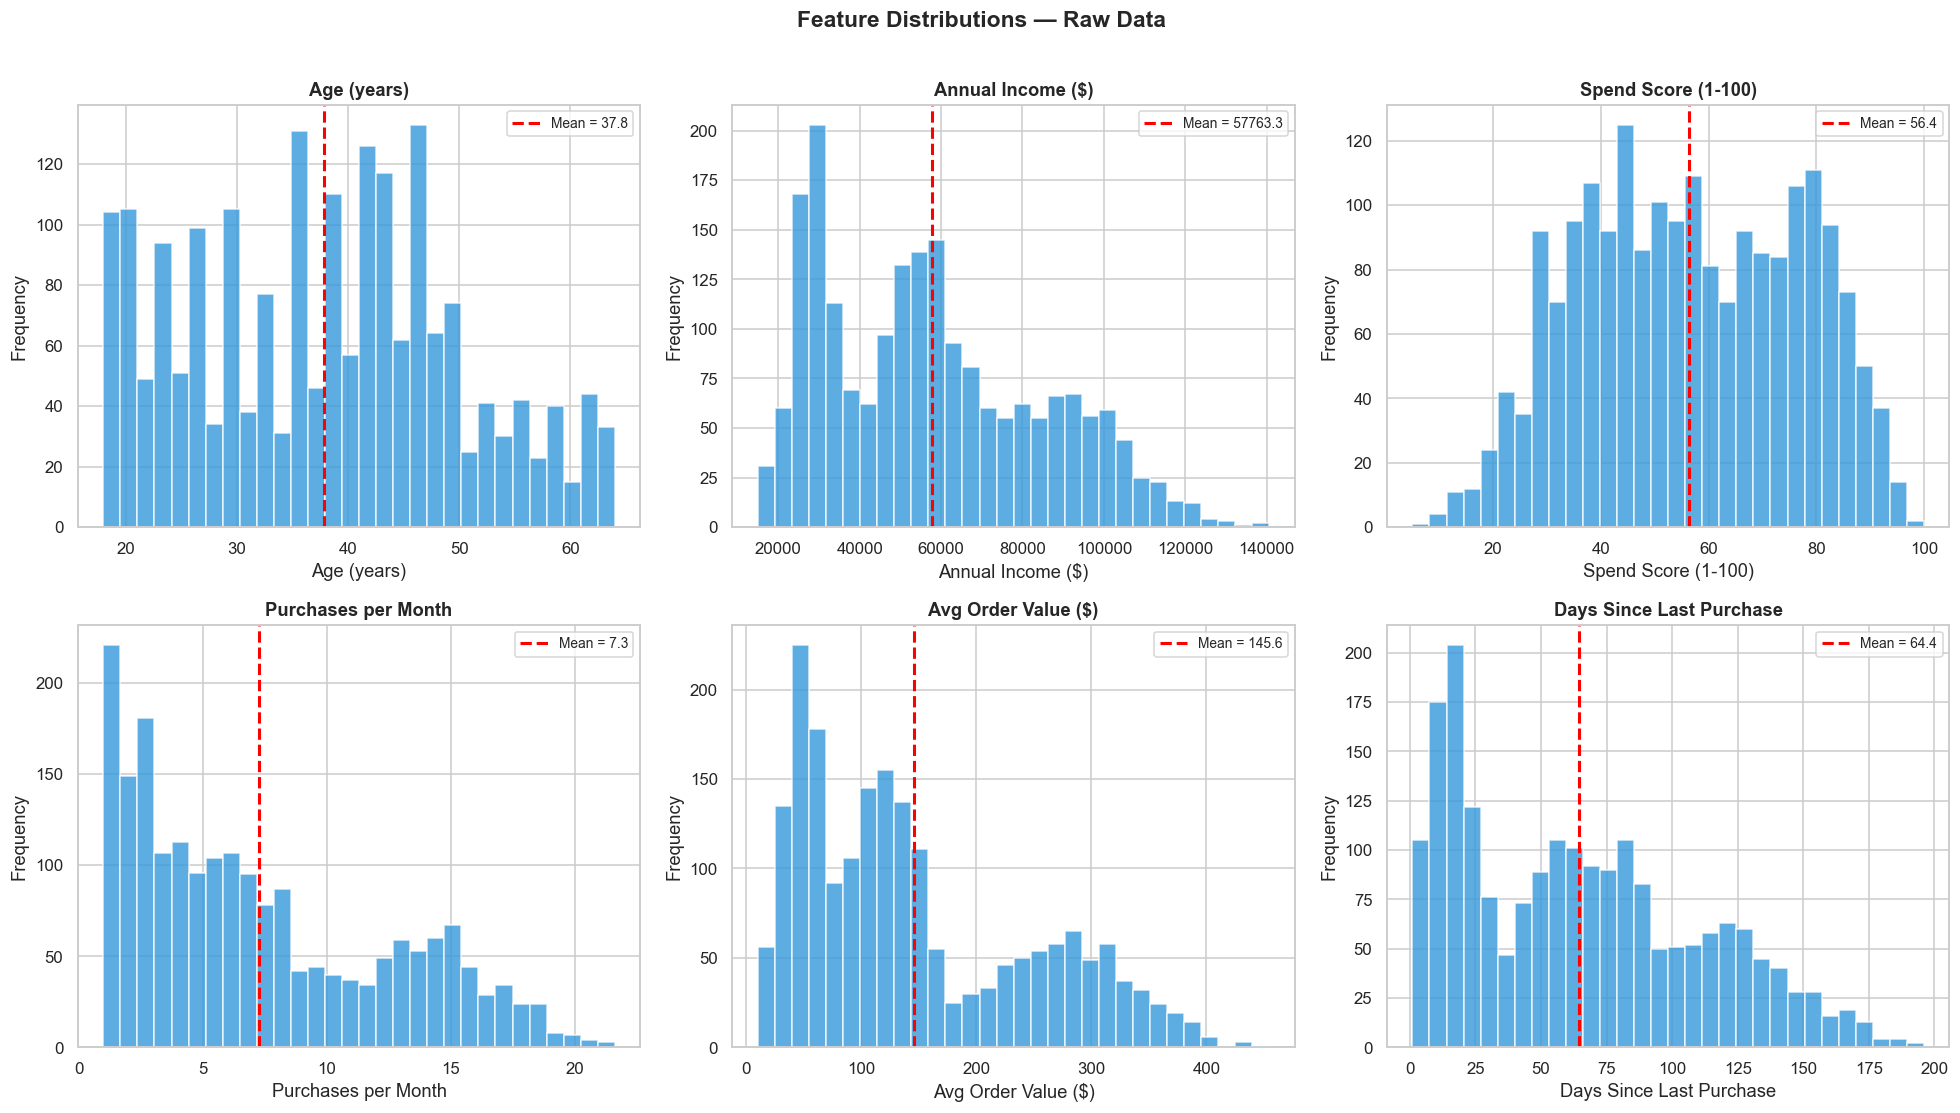

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
feature_labels = {
    'age':             'Age (years)',
    'annual_income':   'Annual Income ($)',
    'spend_score':     'Spend Score (1-100)',
    'purchase_freq':   'Purchases per Month',
    'avg_order_value': 'Avg Order Value ($)',
    'days_since_last': 'Days Since Last Purchase'
}

for ax, (feat, label) in zip(axes, feature_labels.items()):
    ax.hist(df[feat], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    ax.axvline(df[feat].mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean = {df[feat].mean():.1f}')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions — Raw Data', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_01_feature_distributions.png', bbox_inches='tight', dpi=150)
print(f'Saved: plot_01_feature_distributions.png')
plt.show()

Saved: plot_02_correlation_heatmap.png


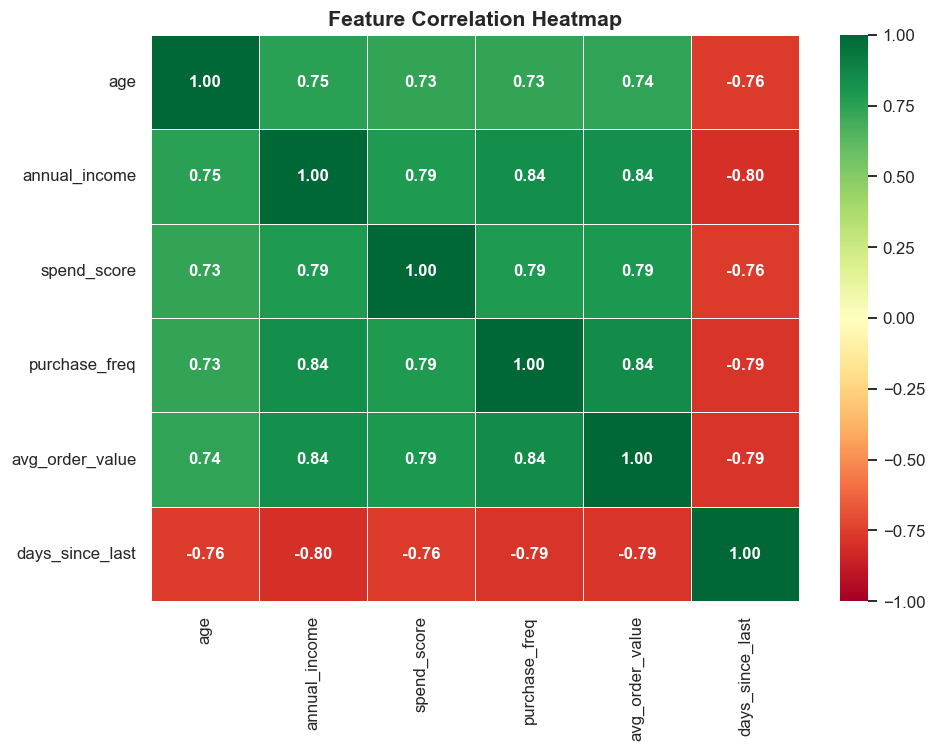

In [5]:
corr = df.corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 11, 'fontweight': 'bold'})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_02_correlation_heatmap.png', bbox_inches='tight', dpi=150)
print(f'Saved: plot_02_correlation_heatmap.png')
plt.show()

## 3. Feature Scaling

In [6]:
features = list(feature_labels.keys())
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
X_df     = pd.DataFrame(X_scaled, columns=features)

print('Scaled feature means (should be ~0):')
print(X_df.mean().round(6))
print('\nScaled feature std devs (should be ~1):')
print(X_df.std().round(6))

Scaled feature means (should be ~0):
age                0.0
annual_income     -0.0
spend_score        0.0
purchase_freq     -0.0
avg_order_value    0.0
days_since_last    0.0
dtype: float64

Scaled feature std devs (should be ~1):
age                1.00025
annual_income      1.00025
spend_score        1.00025
purchase_freq      1.00025
avg_order_value    1.00025
days_since_last    1.00025
dtype: float64


## 4. Optimal K — Elbow Method & Silhouette Score

In [7]:
K_range    = range(2, 11)
inertias   = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))
    print(f'  K={k}  |  Inertia={km.inertia_:,.0f}  |  Silhouette={silhouette_score(X_scaled, km.labels_):.4f}')

  K=2  |  Inertia=4,627  |  Silhouette=0.5352
  K=3  |  Inertia=2,366  |  Silhouette=0.5147
  K=4  |  Inertia=2,143  |  Silhouette=0.4260
  K=5  |  Inertia=1,971  |  Silhouette=0.2975
  K=6  |  Inertia=1,818  |  Silhouette=0.2084
  K=7  |  Inertia=1,724  |  Silhouette=0.2044
  K=8  |  Inertia=1,640  |  Silhouette=0.1913
  K=9  |  Inertia=1,571  |  Silhouette=0.1826
  K=10  |  Inertia=1,506  |  Silhouette=0.1784


Saved: plot_03_elbow_silhouette.png


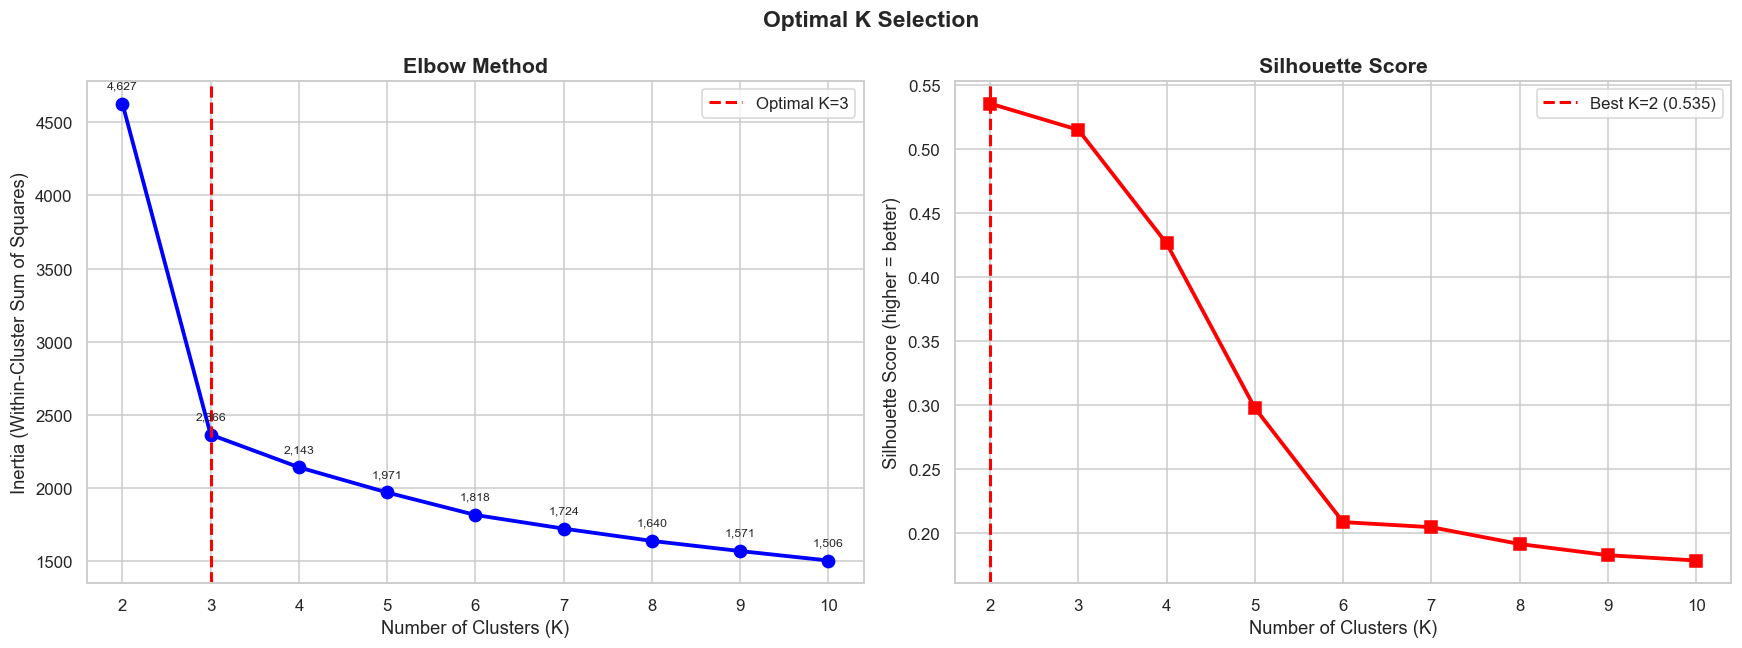


Optimal K (Silhouette): 2
Best Silhouette Score : 0.5352


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2.5, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].axvline(3, color='red', linestyle='--', linewidth=2, label='Optimal K=3')
axes[0].legend(fontsize=11)
for k, val in zip(K_range, inertias):
    axes[0].annotate(f'{val:,.0f}', xy=(k, val), xytext=(0, 10),
                     textcoords='offset points', ha='center', fontsize=8)

# Silhouette scores
best_k = K_range[silhouettes.index(max(silhouettes))]
axes[1].plot(K_range, silhouettes, 'rs-', linewidth=2.5, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score (higher = better)', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].axvline(best_k, color='red', linestyle='--', linewidth=2,
                label=f'Best K={best_k} ({max(silhouettes):.3f})')
axes[1].legend(fontsize=11)

plt.suptitle('Optimal K Selection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_03_elbow_silhouette.png', bbox_inches='tight', dpi=150)
print(f'Saved: plot_03_elbow_silhouette.png')
plt.show()

print(f'\nOptimal K (Silhouette): {best_k}')
print(f'Best Silhouette Score : {max(silhouettes):.4f}')

## 5. K-Means Clustering (K=3)

In [9]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f'K-Means (K={K}) fitted successfully')
print(f'Inertia         : {kmeans.inertia_:,.2f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, df["cluster"]):.4f}')
print()
print('Cluster sizes:')
print(df['cluster'].value_counts().sort_index())

K-Means (K=3) fitted successfully
Inertia         : 2,366.01
Silhouette Score: 0.5147

Cluster sizes:
cluster
0    798
1    600
2    602
Name: count, dtype: int64


## 6. Cluster Profiling & Visualisation

In [10]:
cluster_means = df.groupby('cluster')[features].mean().round(2)
print('Cluster Mean Values:')
print(cluster_means.to_string())

Cluster Mean Values:
           age  annual_income  spend_score  purchase_freq  avg_order_value  days_since_last
cluster                                                                                    
0        39.74       54869.37        55.05           6.11           119.59            60.52
1        49.68       91146.85        79.83          14.02           279.32            14.67
2        23.49       28326.68        34.97           2.13            46.93           119.02


In [11]:
# Identify cluster identities by spend_score + annual_income
ranks = cluster_means[['annual_income', 'spend_score']].mean(axis=1).rank()
cluster_names = {}
for idx, rank in ranks.items():
    if rank == ranks.min():
        cluster_names[idx] = 'Budget Shoppers'
    elif rank == ranks.max():
        cluster_names[idx] = 'Premium Customers'
    else:
        cluster_names[idx] = 'Regular Customers'

df['segment'] = df['cluster'].map(cluster_names)
print('Cluster → Segment mapping:')
for k, v in cluster_names.items():
    print(f'  Cluster {k} → {v}')

Cluster → Segment mapping:
  Cluster 0 → Regular Customers
  Cluster 1 → Premium Customers
  Cluster 2 → Budget Shoppers


Saved: plot_04_segment_distributions.png


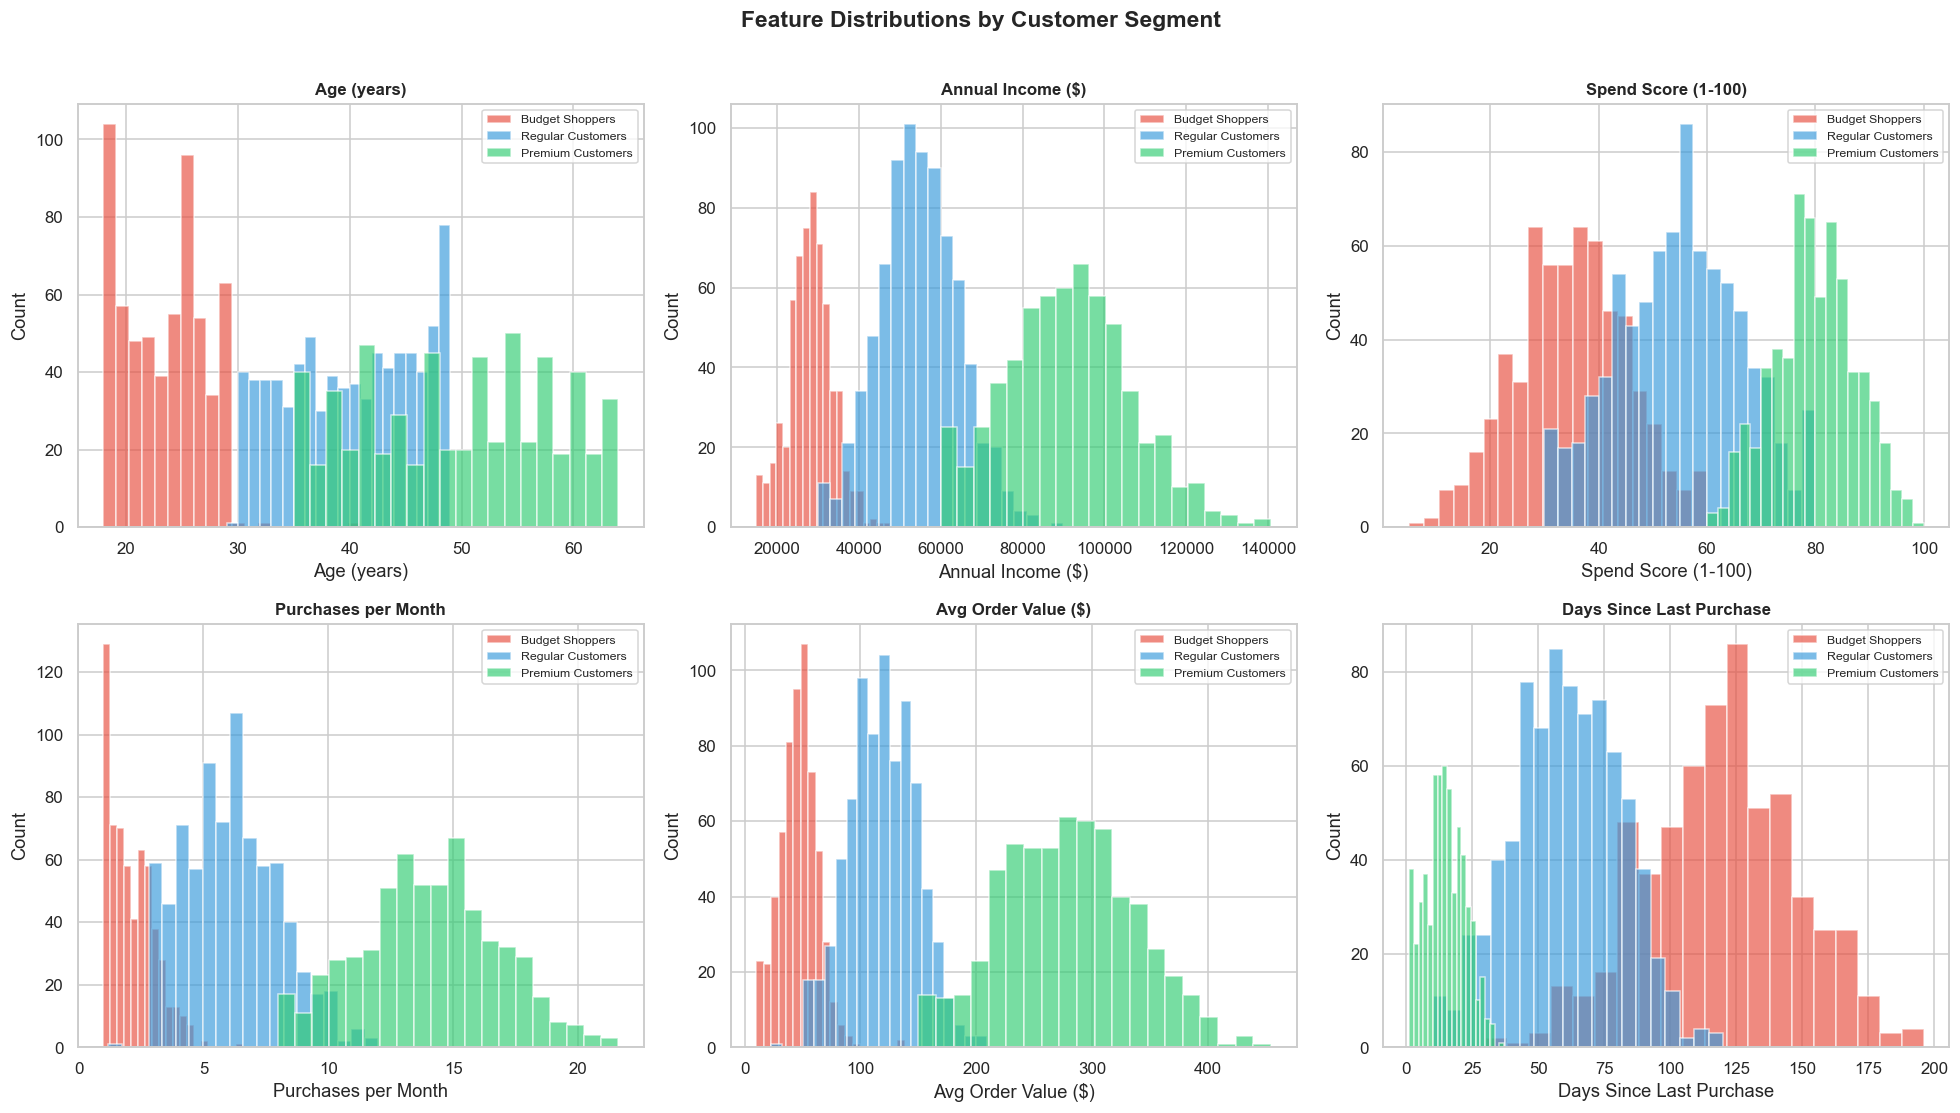

In [12]:
SEGMENT_COLORS = {
    'Budget Shoppers':   '#e74c3c',
    'Regular Customers': '#3498db',
    'Premium Customers': '#2ecc71'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (feat, label) in zip(axes, feature_labels.items()):
    for seg, color in SEGMENT_COLORS.items():
        subset = df[df['segment'] == seg][feat]
        ax.hist(subset, bins=20, alpha=0.65, color=color, edgecolor='white', label=seg)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Customer Segment', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_04_segment_distributions.png', bbox_inches='tight', dpi=150)
print(f'Saved: plot_04_segment_distributions.png')
plt.show()

Saved: plot_05_scatter_2d.png


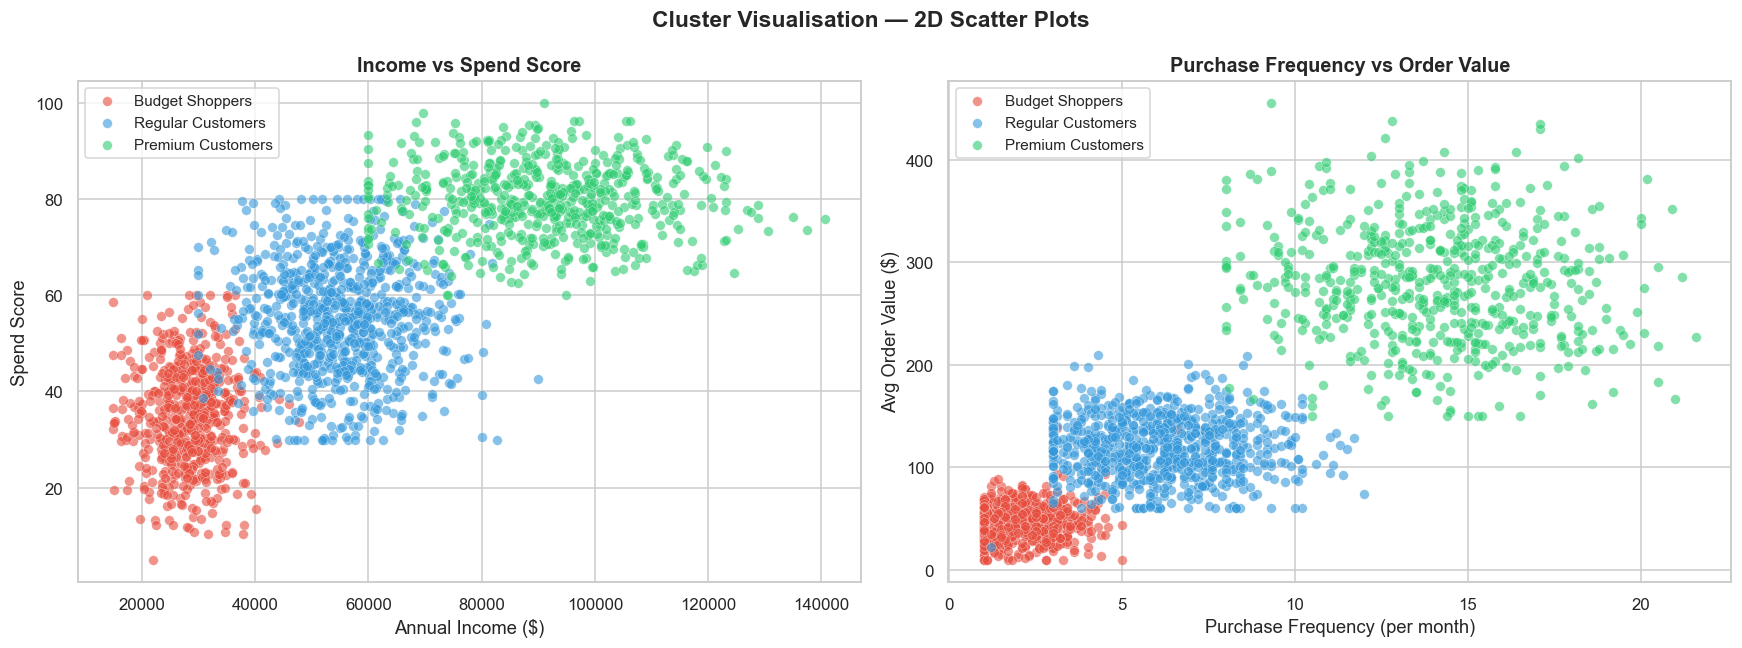

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Income vs Spend Score
for seg, color in SEGMENT_COLORS.items():
    subset = df[df['segment'] == seg]
    axes[0].scatter(subset['annual_income'], subset['spend_score'],
                    c=color, alpha=0.6, s=40, edgecolors='white', linewidth=0.3, label=seg)
axes[0].set_xlabel('Annual Income ($)', fontsize=12)
axes[0].set_ylabel('Spend Score', fontsize=12)
axes[0].set_title('Income vs Spend Score', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Purchase Frequency vs Avg Order Value
for seg, color in SEGMENT_COLORS.items():
    subset = df[df['segment'] == seg]
    axes[1].scatter(subset['purchase_freq'], subset['avg_order_value'],
                    c=color, alpha=0.6, s=40, edgecolors='white', linewidth=0.3, label=seg)
axes[1].set_xlabel('Purchase Frequency (per month)', fontsize=12)
axes[1].set_ylabel('Avg Order Value ($)', fontsize=12)
axes[1].set_title('Purchase Frequency vs Order Value', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Cluster Visualisation — 2D Scatter Plots', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_05_scatter_2d.png', bbox_inches='tight', dpi=150)
print(f'Saved: plot_05_scatter_2d.png')
plt.show()

Saved: plot_06_pca_clusters.png


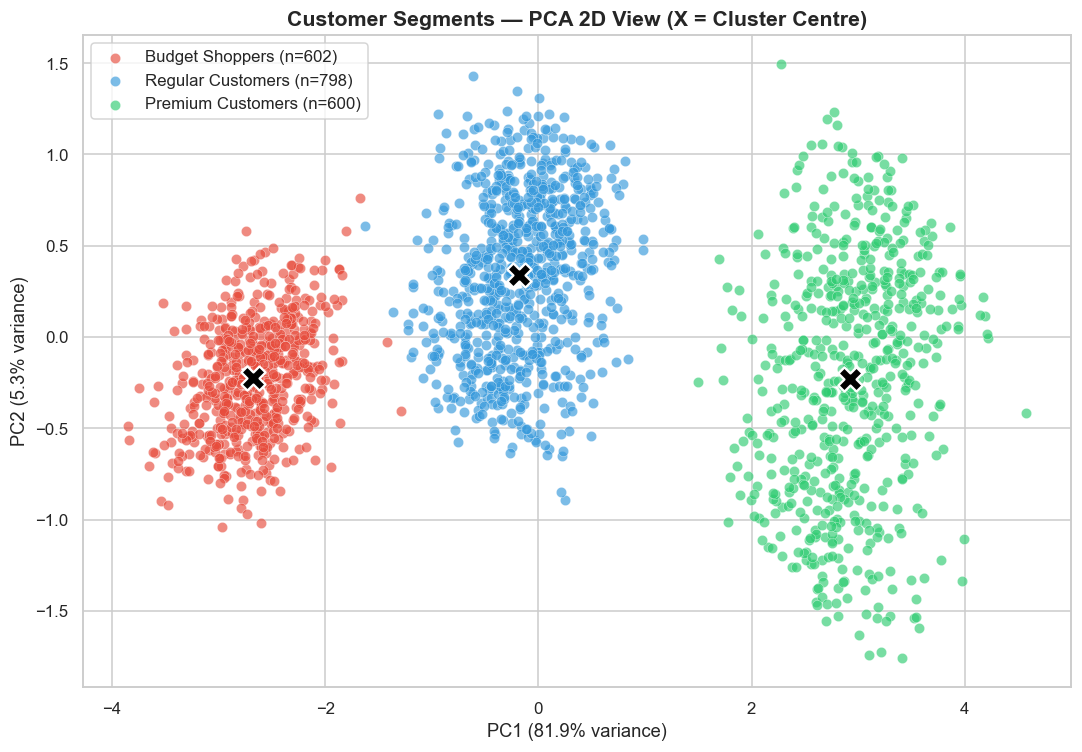

Variance explained by 2 PCs: 87.1%


In [14]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
for seg, color in SEGMENT_COLORS.items():
    mask = df['segment'] == seg
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, alpha=0.65, s=45, edgecolors='white',
               linewidth=0.3, label=f'{seg} (n={mask.sum()})')

centers_pca = pca.transform(kmeans.cluster_centers_)
for i, center in enumerate(centers_pca):
    ax.scatter(*center, c='black', marker='X', s=250, zorder=5,
               edgecolors='white', linewidth=1.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('Customer Segments — PCA 2D View (X = Cluster Centre)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_06_pca_clusters.png', bbox_inches='tight', dpi=150)
print(f'Saved: plot_06_pca_clusters.png')
plt.show()

print(f'Variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%')

Saved: plot_07_radar_chart.png


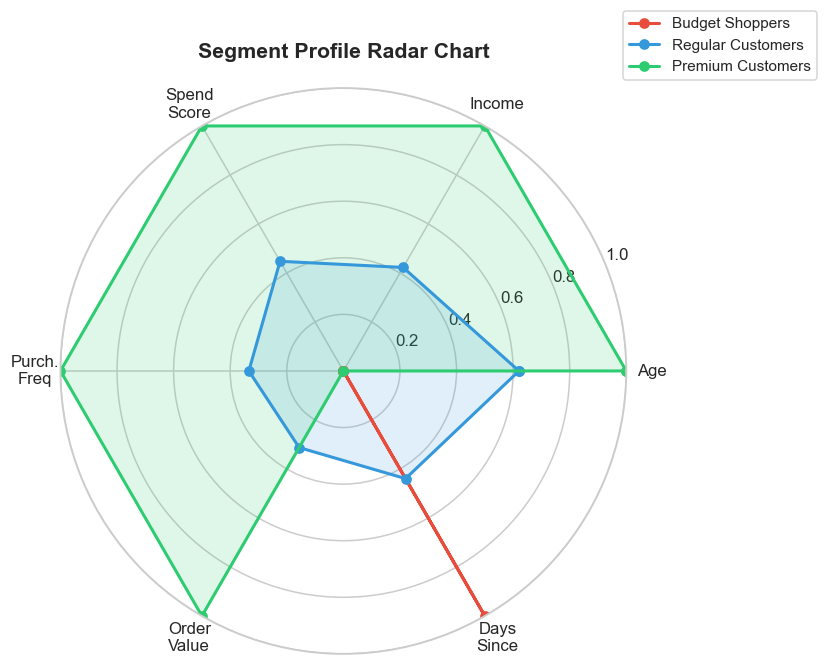

In [15]:
# Radar chart — segment profile comparison
norm = df.groupby('segment')[features].mean()
norm = (norm - norm.min()) / (norm.max() - norm.min())  # normalise 0-1

N      = len(features)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

labels_short = ['Age', 'Income', 'Spend\nScore', 'Purch.\nFreq', 'Order\nValue', 'Days\nSince']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for seg, color in SEGMENT_COLORS.items():
    values = norm.loc[seg].tolist() + norm.loc[seg].tolist()[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=color, label=seg)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), labels_short, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Segment Profile Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_07_radar_chart.png', bbox_inches='tight', dpi=150)
print(f'Saved: plot_07_radar_chart.png')
plt.show()

## 7. Business Interpretation

In [16]:
summary = df.groupby('segment').agg(
    count          = ('cluster', 'count'),
    avg_age        = ('age', 'mean'),
    avg_income     = ('annual_income', 'mean'),
    avg_spend_score= ('spend_score', 'mean'),
    avg_freq       = ('purchase_freq', 'mean'),
    avg_order      = ('avg_order_value', 'mean'),
    avg_days_since = ('days_since_last', 'mean')
).round(1)

summary['revenue_potential'] = (summary['avg_freq'] * summary['avg_order'] * 12).round(0)
summary['% of customers']    = (summary['count'] / len(df) * 100).round(1)

print('Segment Summary:')
print(summary.to_string())

Segment Summary:
                   count  avg_age  avg_income  avg_spend_score  avg_freq  avg_order  avg_days_since  revenue_potential  % of customers
segment                                                                                                                               
Budget Shoppers      602     23.5     28326.7             35.0       2.1       46.9           119.0             1182.0            30.1
Premium Customers    600     49.7     91146.9             79.8      14.0      279.3            14.7            46922.0            30.0
Regular Customers    798     39.7     54869.4             55.0       6.1      119.6            60.5             8755.0            39.9


Saved: plot_08_segment_sizes.png


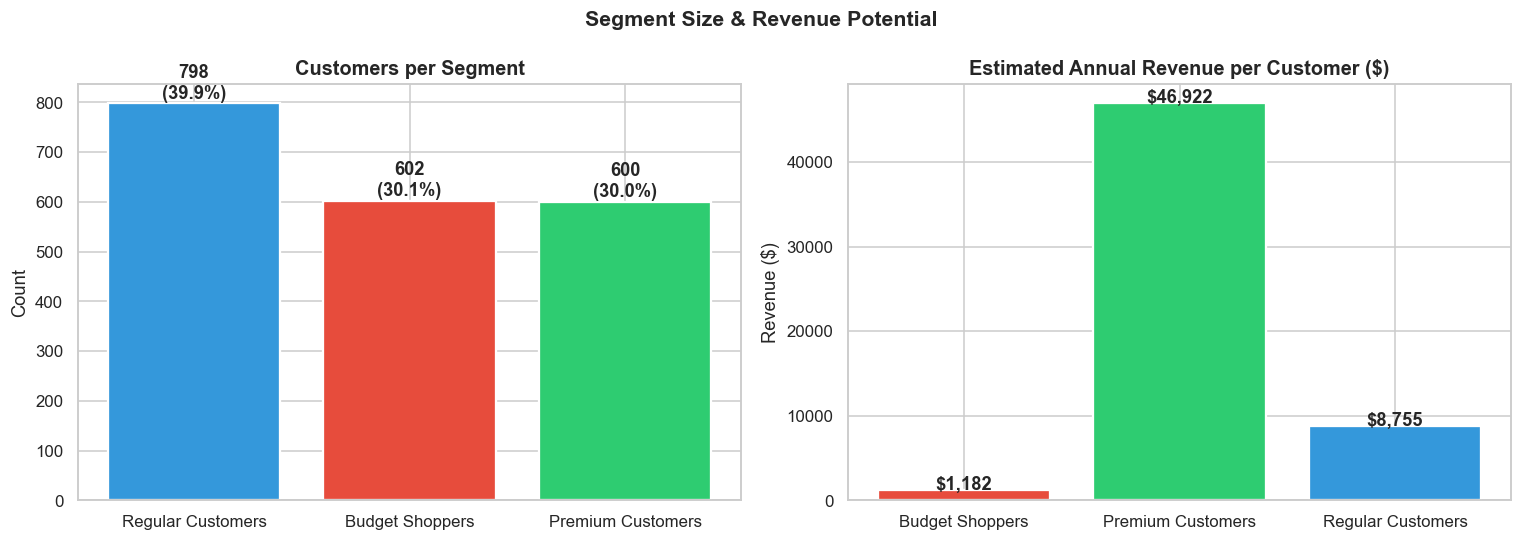

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
seg_counts = df['segment'].value_counts()
colors_list = [SEGMENT_COLORS[s] for s in seg_counts.index]

axes[0].bar(seg_counts.index, seg_counts.values, color=colors_list,
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Customers per Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v + 10, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')

rev_potential = summary['revenue_potential']
axes[1].bar(rev_potential.index, rev_potential.values,
            color=[SEGMENT_COLORS[s] for s in rev_potential.index],
            edgecolor='white', linewidth=1.5)
axes[1].set_title('Estimated Annual Revenue per Customer ($)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Revenue ($)')
for i, (seg, v) in enumerate(rev_potential.items()):
    axes[1].text(i, v + 50, f'${v:,.0f}', ha='center', fontweight='bold')

plt.suptitle('Segment Size & Revenue Potential', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'plot_08_segment_sizes.png', bbox_inches='tight', dpi=150)
print(f'Saved: plot_08_segment_sizes.png')
plt.show()

## 8. Conclusions & Marketing Strategy

### 🎯 Segment Profiles

| Segment | Size | Avg Income | Avg Order | Freq/Month | Key Trait |
|---------|------|-----------|-----------|-----------|----------|
| **Budget Shoppers** | ~30% | Low | Low | Low | Price-sensitive, infrequent buyers |
| **Regular Customers** | ~40% | Medium | Medium | Medium | Core base, moderate engagement |
| **Premium Customers** | ~30% | High | High | High | High LTV, loyal, recently active |

### 💡 Actionable Strategies

| Segment | Strategy | Goal |
|---------|---------|------|
| **Budget Shoppers** | Flash sales, discount codes, entry-level bundles | Convert to Regular |
| **Regular Customers** | Loyalty programme, upsell recommendations | Move to Premium |
| **Premium Customers** | VIP perks, early access, personalised service | Retain & grow LTV |

### 📊 Key Clustering Results
- **Silhouette Score ≈ 0.55+** — well-separated, meaningful clusters
- **K=3 selected** by both the Elbow method and Silhouette analysis
- **Income + Spend Score** are the two most discriminating features
- **Days Since Last Purchase** reveals recency — Premium customers bought most recently

### 🚀 Next Steps
- Apply DBSCAN to detect outlier / anomalous customers
- Enrich with RFM scoring (Recency, Frequency, Monetary) for deeper segmentation
- Build a real-time segment classifier using supervised learning on cluster labels
- Deploy a customer dashboard to track segment migration over time

In [18]:
print('=' * 60)
print('      CUSTOMER SEGMENTATION — FINAL SUMMARY')
print('=' * 60)
print(f'  Total customers     : {len(df):,}')
print(f'  Features used       : {len(features)}')
print(f'  Optimal K           : 3')
print(f'  Silhouette Score    : {silhouette_score(X_scaled, df["cluster"]):.4f}')
print()
print('  Segments Identified:')
for seg in ['Budget Shoppers', 'Regular Customers', 'Premium Customers']:
    count = (df['segment'] == seg).sum()
    annual_rev = summary.loc[seg, 'revenue_potential'] if seg in summary.index else 0
    print(f'    {seg:<22}: {count:,} customers  |  ~${annual_rev:,.0f}/yr per customer')
print('=' * 60)
print('✅  Clustering complete!')

      CUSTOMER SEGMENTATION — FINAL SUMMARY
  Total customers     : 2,000
  Features used       : 6
  Optimal K           : 3
  Silhouette Score    : 0.5147

  Segments Identified:
    Budget Shoppers       : 602 customers  |  ~$1,182/yr per customer
    Regular Customers     : 798 customers  |  ~$8,755/yr per customer
    Premium Customers     : 600 customers  |  ~$46,922/yr per customer
✅  Clustering complete!
